## Problem 8.2 - Classification with Kernel

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import LinearSegmentedColormap

In [55]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

### Approach 1: perform MLR as in exercise 2.3

In [92]:
# create data set of cencentric circles
X, y = make_circles(n_samples = 500, factor = 0.7, noise = 0.12, random_state = 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)


In [93]:
# perform MLR on the data
logistic_reg = LogisticRegression()
logistic_reg.fit(X_train, y_train)
y_pred_logistic = logistic_reg.predict(X_test)

[]

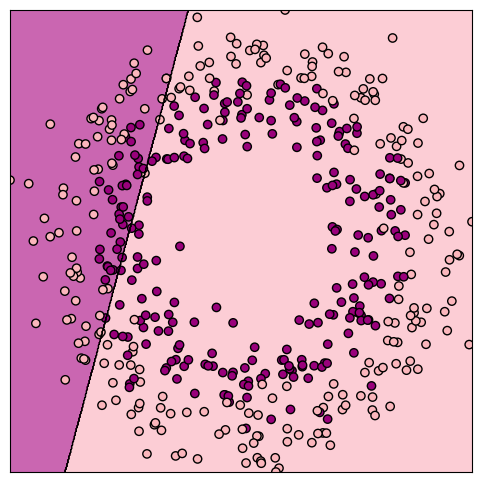

In [ ]:
# plot the decision boundary of MLR and the data points (copied from exercise 2.3)
fig = plt.figure(figsize = (8, 6))
ax = fig.add_subplot()
x0, x1 = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
    np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
)
x_new = np.c_[x0.ravel(), x1.ravel()]
y_pred = logistic_reg.predict(x_new)
zz = y_pred.reshape(x0.shape)

plt.contourf(x0, x1, zz, alpha = 0.6, cmap = truncated_RdPu)
plt.contour(x0, x1, zz, colors = ['black'], linewidths = [0.4])
plt.scatter(X[:,0], X[:,1], c = y, edgecolors = 'k', cmap = truncated_RdPu)
ax.set_box_aspect(1)
ax.xaxis.set_tick_params(labelbottom = False)
ax.yaxis.set_tick_params(labelleft = False)
ax.set_xticks([])
ax.set_yticks([])

In [95]:
# compute the scores of the MLR on train and test set
accuracy_train_logistic = np.mean(logistic_reg.predict(X_train) == y_train)
print(f'Logistic Regression Training Accuracy: {accuracy_train_logistic:.2f}')
accuracy_logistic = np.mean(y_pred_logistic == y_test)
print(f'Logistic Regression Test Accuracy: {accuracy_logistic:.2f}')

Logistic Regression Training Accuracy: 0.46
Logistic Regression Test Accuracy: 0.36


### Approach 2: Repeat the experiment but under the feature map phi:

In [96]:
def phi(x):
    x1 = x[:, 0]
    x2 = x[:, 1]
    x1x2 = x1**2 + x2**2        
    return np.column_stack((x1, x2, x1x2))

In [97]:
# train MLR on the feature mapped data
X_train_phi = phi(X_train)
X_test_phi = phi(X_test)

logistic_reg_phi = LogisticRegression()
logistic_reg_phi.fit(X_train_phi, y_train)
y_pred_logistic_phi = logistic_reg_phi.predict(X_test_phi)

[]

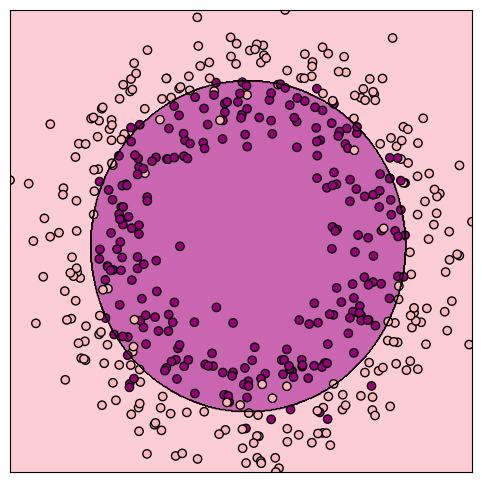

In [98]:
# plot again the decision boundary of MLR on the feature mapped data
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot()
x0, x1 = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
    np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
)
x_new = np.c_[x0.ravel(), x1.ravel()]
x_new_phi = phi(x_new)
y_pred = logistic_reg_phi.predict(x_new_phi)
zz = y_pred.reshape(x0.shape)

plt.contourf(x0, x1, zz, alpha=0.6, cmap=truncated_RdPu)
plt.contour(x0, x1, zz, colors=['black'], linewidths=[0.4])
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=truncated_RdPu)

ax.set_box_aspect(1)
ax.xaxis.set_tick_params(labelbottom=False)
ax.yaxis.set_tick_params(labelleft=False)
ax.set_xticks([])
ax.set_yticks([])


In [99]:
# print the scores of MLR on the feature mapped data
accuracy_train_logistic_phi = np.mean(logistic_reg_phi.predict(X_train_phi) == y_train)
print(f'Logistic Regression with Feature Map Training Accuracy: {accuracy_train_logistic_phi:.2f}')
accuracy_logistic_phi = np.mean(y_pred_logistic_phi == y_test)
print(f'Logistic Regression with Feature Map Test Accuracy: {accuracy_logistic_phi:.2f}')


Logistic Regression with Feature Map Training Accuracy: 0.89
Logistic Regression with Feature Map Test Accuracy: 0.92
